In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [2]:
#Sub-category sales
subcat_sales=df.groupby('sub-category')['sales'].sum().sort_values(ascending=False).reset_index()
subcat_sales

,sub-category,sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_9384\1968886986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_sales,x='sub-category',y='sales',palette='viridis')


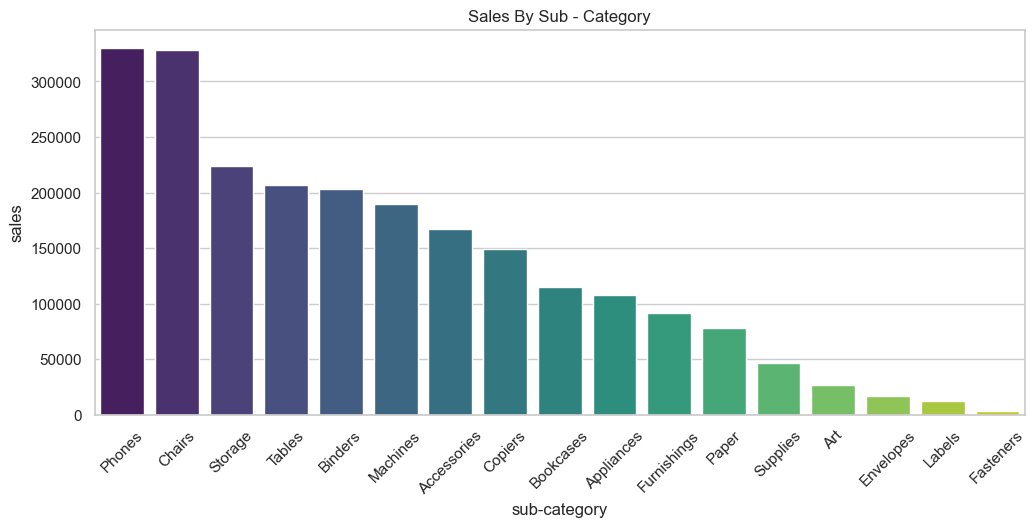

In [4]:
# Plot sub-category sales
plt.figure(figsize=(12,5))
sns.barplot(data=subcat_sales,x='sub-category',y='sales',palette='viridis')
plt.title('Sales By Sub - Category')
plt.xticks(rotation=45)
plt.savefig('../visuals/sales-bysub-category.png',dpi=150,bbox_inches='tight')
plt.show()

Phones and Chairs are the top revenue generators (~330K each), followed by Storage and Tables. Fasteners, Labels, and Envelopes are the weakest. The top 2 sub-categories alone account for nearly 30% of total sales.

In [5]:
# Sub-category profit
subcat_profit=df.groupby('sub-category')['profit'].sum().sort_values(ascending=False).reset_index()
subcat_profit

,sub-category,profit
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633
5,Chairs,26590.1663
6,Storage,21278.8264
7,Appliances,18138.0054
8,Furnishings,13059.1436
9,Envelopes,6964.1767


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_9384\741467873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_profit,x='sub-category',y='profit',palette='coolwarm')


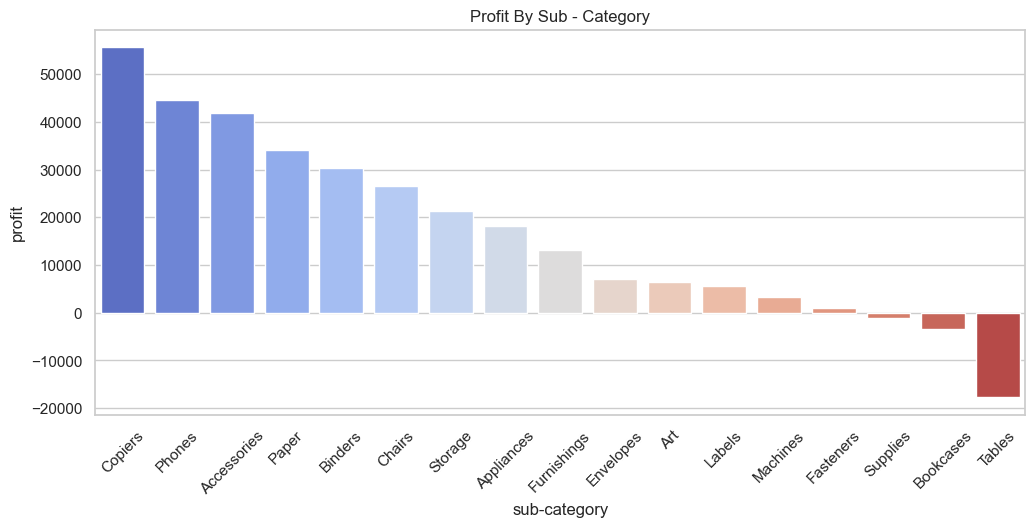

In [6]:
#Plot sub-category profit
plt.figure(figsize=(12,5))
sns.barplot(data=subcat_profit,x='sub-category',y='profit',palette='coolwarm')
plt.title('Profit By Sub - Category')
plt.xticks(rotation=45)
plt.savefig('../visuals/profit-by-sub-category.png',dpi=150,bbox_inches='tight')
plt.show()

Copiers, Phones, and Accessories are the most profitable sub-categories. But look at the right side — Tables (~-18K) and Bookcases (~-3K) have negative total profit. These two are Furniture sub-categories. They are generating decent sales but are actively losing money. This confirms the Furniture margin problem that I spotted on Day 2

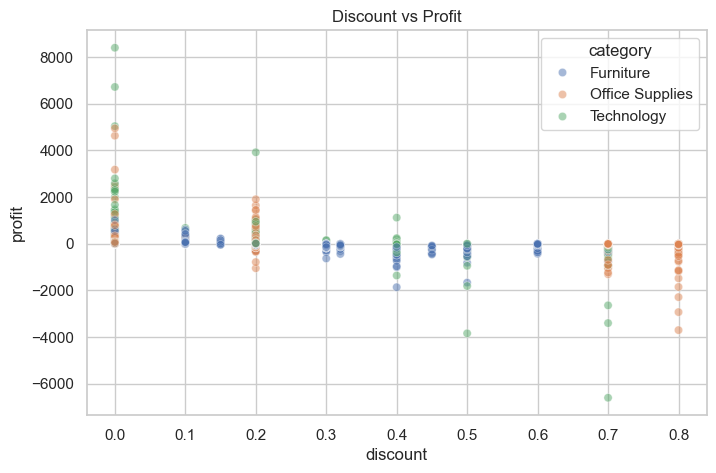

In [7]:
#Discount vs profit scatter
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='discount',y='profit',hue='category',alpha=0.5)
plt.title('Discount vs Profit')
plt.savefig('../visuals/discount-vs-profit.png',dpi=150,bbox_inches='tight')
plt.show()

The pattern is very clear — at discount = 0, profits are positive and high. As discount increases past 0.3–0.4, profits start going negative across all categories. At discount = 0.7 and 0.8, almost every order is a loss. Heavy discounting is the direct cause of negative profit.

In [8]:
df.groupby('category')[['discount','sales','profit']].mean().reset_index()

,category,discount,sales,profit
0,Furniture,0.173923,349.834887,8.699327
1,Office Supplies,0.157285,119.324101,20.327050
2,Technology,0.132323,452.709276,78.752002


## 4.Does discounting hurt profit?
#### Yes — discounts above 30% consistently cause losses

## 5. Which sub-categories are loss-making?
#### Tables and Bookcases — negative total profit